# Stable Diffusion Inference Demo

This notebook demonstrates how to use a custom Stable Diffusion model for text-to-image and image-to-image generation.

## Overview

This implementation includes:
- Text-to-image generation
- Image-to-image generation (optional)
- Classifier-free guidance (CFG)
- Multiple sampler options
- Custom model loading from pretrained weights

## 1. Setup and Imports

Import required libraries and set up the environment.

In [34]:
import model_loader
import pipeline
from PIL import Image
from pathlib import Path
from transformers import CLIPTokenizer
import torch

## 2. Device Configuration

Configure which device to use for inference. CPU is used by default for compatibility.
Set `ALLOW_CUDA = True` to enable GPU acceleration if available.

In [35]:
DEVICE = "cpu"

ALLOW_CUDA = True
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = "cuda"
elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Model Loading

Load the CLIP tokenizer and Stable Diffusion models from pretrained weights.

In [36]:
tokenizer = CLIPTokenizer("../data/vocab.json", merges_file="../data/merges.txt")
model_file = "../data/v1-5-pruned-emaonly.ckpt"
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE)

## 4. Text-to-Image Configuration

Configure the prompt and generation parameters for text-to-image synthesis.

In [37]:
prompt = "A flying elephant with blue fur and an iPad."
uncond_prompt = ""  # Also known as negative 
do_cfg = True
cfg_scale = 8  # min: 1, max: 14

## 5. Image-to-Image Configuration (Optional)

Configure image-to-image generation. Currently disabled by default.
Uncomment the relevant lines to enable image-to-image functionality.

In [38]:
input_image = None
# Comment to disable image to image
image_path = "../images/doggy.jpg"
# input_image = Image.open(image_path)
# Higher values means more noise will be added to the input image, so the result will further from the input image.
# Lower values means less noise is added to the input image, so output will be closer to the input image.
strength = 0.2

## 6. Sampler Configuration

Configure the sampling parameters including the sampler type, number of inference steps, and random seed.

In [39]:
sampler = "ddpm"
num_inference_steps = 50
seed = 42

## 7. Generate Image

Run the diffusion pipeline to generate the image based on the configured parameters.

In [40]:
output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer,
)

timesteps: tensor([980, 960, 940, 920, 900, 880, 860, 840, 820, 800])


100%|██████████| 50/50 [00:20<00:00,  2.42it/s]


## 8. Display Result

Display the generated image.

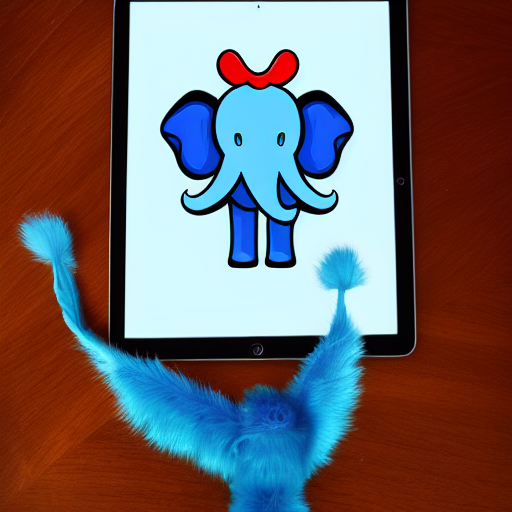

In [41]:
# Display the generated image
Image.fromarray(output_image)